In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.utils import shuffle

![data_visualization_3](./images/37_page.jpg)

![data_visualization_3](./images/38_page.jpg)

# Model evaluation

Be the algorithm
- solve manually
- if you can't, can you expect a machine too?

Look at the samples you get wrong
- best, worst, uncertain (50% probability in classification)

## Train / test / validation / holdout

### Train

- used to find statistics & parameters of a model

### Validation

- aka test
- used to find hyperparameters & select a model
- should both be representative of new/future data

### Holdout

- aka test
- how well did my final model do
- should be representative of new/future data
- use a test set to evaluate the performance of the model selected using the previous steps

## Metrics

Align with a business objective / product
- possible to have a good ML model with a bad product

Most are **aggregates**
- lose/hide infomation

### Classification metrics

### Confusion matrix

![tp_fp](./images/tp_fp.png)

|  | 0 | 1 |
| --- | --- | --- |
| 0| tn | fn |
| 1| fp | tp |


### Precision
- tp / (tp + fp)
- how many positive predictions were correct
- false detection
- fraction of all predictions of class 1 that are correct
- minimize false positives

### Recall
- tp / (tp + fn)
- how many positives did I detect out of all the positives
- misses
- how many of the true class 1 did I predict

**Note that only one term changes in the definitions of precision & recall!**
- whether you are dealing with fp (precision) or fn (recall)

Always tradeoff between precision & recall

Predicitive maintenance
- false positives = ok, false negatives = not ok

## True / false positive rates

Measuring p with r = nonsense
- can maximize one at the cost of the other

F1

Area under ROC
- 1 = perfect, 0.5 = random
- use for classifiers that can modify a threshold
- summarizes tradeoffs in varying the threshold
- what does under the line of ROC mean?

Threshold tuning

Average precision
- averaged over all recalls

Create an imbalanced dataset, by selecting only the sevens:

In [2]:

data = load_digits()

y = data.target
x = data.data / 255

noise = np.random.random(size=x.size).reshape(x.shape)
x += noise * 0.5
y = (y == 3).astype(int)

In [3]:
np.mean(y)

np.float64(0.1018363939899833)

In [4]:
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='lbfgs')

model.fit(x, y)

probs = model.decision_function(x)

In [5]:
probs

array([-3.82506137, -3.20875412, -1.40461223, ..., -2.6331319 ,
       -1.72888712, -2.41770953], shape=(1797,))

0.7254792424211645


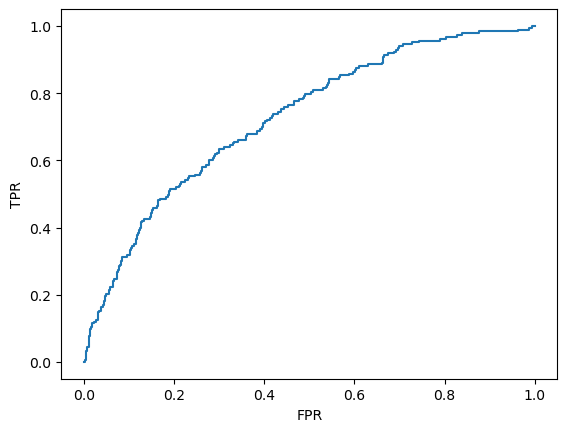

In [6]:
fpr, tpr, thresholds = roc_curve(y, probs)

roc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
print(roc)

### Regression metrics

MAE

MSE

RMSE

MAPE

MASE

MAPE is not symmetric
- puts a heavier penalty on negative errors

In [7]:
def mape(pred, act):
    return abs((pred - act) / act)

In [8]:
print(mape(100, 90))
print(mape(100, 110))

0.1111111111111111
0.09090909090909091


In [12]:
import sys
sys.path.append('..')

from sklearn.model_selection import cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.datasets import load_iris

## Splitting datasets (train or validation)

Be careful with random sampling of datasets - **data leakage**
- predicting the past from the future
- duplicates

In [25]:
# ds = load_iris()

ds = pd.read_csv('./data/Iris.csv')

ds.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
y = ds.Species
x = ds.drop('Species',axis=1)

## Test set

Let's follow a best practice and split off a test set.  Reason for this is:
- unseen data for a final measure of generalization error
- only ever do one forward pass on this dataset

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
assert x_train.shape[0] > x_test.shape[0]

In [29]:
x_train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
73,74,6.1,2.8,4.7,1.2
98,99,5.1,2.5,3.0,1.1
16,17,5.4,3.9,1.3,0.4
29,30,4.7,3.2,1.6,0.2
14,15,5.8,4.0,1.2,0.2


In [30]:
x_test.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
123,124,6.3,2.7,4.9,1.8
36,37,5.5,3.5,1.3,0.2
1,2,4.9,3.0,1.4,0.2
87,88,6.3,2.3,4.4,1.3
124,125,6.7,3.3,5.7,2.1


In [31]:
y_train

73     Iris-versicolor
98     Iris-versicolor
16         Iris-setosa
29         Iris-setosa
14         Iris-setosa
            ...       
105     Iris-virginica
43         Iris-setosa
19         Iris-setosa
9          Iris-setosa
94     Iris-versicolor
Name: Species, Length: 120, dtype: object

## Cross-validation

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html

https://scikit-learn.org/stable/modules/naive_bayes.html

CV
- use for hyperparams
- use all your data for test & train
- large K = small test set sizes
- computationally expensive
- avoid fitting your test set

When not to randomly sample
- time series

Cross validation = randomly sample!
- see [sklearn.model_selection.TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

Pick a model and do cross-validation.  Reasons for this:
- use all data
- don't overfit holdout set

In [32]:
model = GaussianNB(priors=[1/3 for _ in range(3)])

#  defaults to stratified KFold
results = cross_validate(
    model, 
    x_train, 
    y_train.values.flatten(), 
    scoring='accuracy', 
    cv=3,
    return_train_score=True
)

In [33]:
pd.DataFrame(results)

,fit_time,score_time,test_score,train_score
0,0.008182,0.003664,1.000,1.0000
1,0.001433,0.001005,1.000,0.9875
2,0.001254,0.001044,0.975,1.0000


## Grid search + cross-validation

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Most of the time these occur together

In [22]:
from sklearn.model_selection import GridSearchCV

def make_prior(logits):
    s = sum(logits)
    return [e / s for e in logits]

params = {
    'n_estimators': [1, 10, 100],
    'max_features': [1, 2, 3]
}

model = RandomForestClassifier()

gs = GridSearchCV(model, params, cv=5, return_train_score=True)
gs.fit(x_tr, y_tr.values.reshape(-1, ))

res = gs.cv_results_
print(res.keys())

res = pd.DataFrame(res)

cols = [r for r in res.columns if ('score' in r and 'mean' in r)]

print(np.max(res.loc[:, 'mean_test_score']))
res.loc[:, cols]

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_features', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])
1.0


,mean_score_time,mean_test_score,mean_train_score
0,0.001222,0.977778,0.985185
1,0.001395,0.977778,1.000000
2,0.003802,0.985185,1.000000
3,0.000842,0.985185,0.979630
4,0.001167,0.992593,1.000000
5,0.003694,1.000000,1.000000
6,0.000799,0.985185,0.979630
7,0.001098,0.985185,1.000000
8,0.003544,0.992593,1.000000


## Random search + cross-validation

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

Random search is better (so they say)

In [23]:
from sklearn.model_selection import RandomizedSearchCV

import scipy.stats as stats

params = {
    'n_estimators': stats.randint(10, 1000),
    'max_features': stats.randint(1, 3),
    'max_depth': stats.randint(1, 30)
}

model = RandomForestClassifier()

rs = RandomizedSearchCV(model, params, cv=5, return_train_score=True, n_iter=32)
rs.fit(x_tr, y_tr.values.reshape(-1, ))

res = rs.cv_results_
res = pd.DataFrame(res)
cols = [r for r in res.columns if ('score' in r and 'mean' in r)]
print(np.max(res.loc[:, 'mean_test_score']))
res.loc[:, cols]

1.0


,mean_score_time,mean_test_score,mean_train_score
0,0.010385,0.992593,1.0
1,0.006107,0.992593,1.0
2,0.006602,1.000000,1.0
3,0.013247,0.985185,1.0
4,0.006516,0.977778,1.0
5,0.006701,0.985185,1.0
6,0.025890,1.000000,1.0
7,0.006465,0.992593,1.0
8,0.021448,1.000000,1.0
9,0.025890,1.000000,1.0


## A closer look at cross-validation

In [24]:
import sys
sys.path.append('..')
from common import load_forest_fires

ModuleNotFoundError: No module named 'common'

In [ ]:
forest = load_forest_fires()

In [ ]:
model = RandomForestRegressor(n_estimators=50)

x = forest.loc[:, ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']]
y = forest.loc[:, 'area']

from sklearn.metrics import mean_absolute_error

res = []
for _ in range(10):
    x, y = shuffle(x, y)
    
    results = cross_validate(
        model, 
        x, 
        y.values.flatten(), 
        scoring='neg_mean_absolute_error',
        cv=3,
        return_train_score=True
    )

    res.append(results['test_score'])
 
res = pd.DataFrame(res)
res.loc[:, 'avg'] = res.loc[:, :].mean(axis=1)
res

In [ ]:
res.min().min() ,res.max().max()

This noise is unavoidable!

## References

[Understanding and diagnosing your machine-learning models - Gaël Varoquaux](https://www.youtube.com/watch?v=kbj3llSbaVA)